# Component 2 · Task 1 — Quantum Harmonic Oscillator: Operators and Energy Spectrum
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** Construct the quantum position, momentum, and Hamiltonian operators as truncated matrices using QuTiP, visualize their structure, and compute the energy spectrum.

## Part (a) — Constructing the operators

We build $\hat{x}$, $\hat{p}$, and $\hat{H}$ from the ladder (creation/annihilation) operators:

$$\hat{x} = \sqrt{\frac{\hbar}{2m\omega}}\left(\hat{a} + \hat{a}^\dagger\right), \qquad
\hat{p} = -i\sqrt{\frac{\hbar m \omega}{2}}\left(\hat{a} - \hat{a}^\dagger\right)$$

$$\hat{H} = \frac{\hat{p}^2}{2m} + \frac{1}{2}m\omega^2\hat{x}^2$$

`destroy(N)` gives the truncated $N\times N$ matrix representation of $\hat{a}$; `.dag()` gives its Hermitian conjugate $\hat{a}^\dagger$.

In [ ]:
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

# Parameters
N = 20      # Hilbert-space dimension
hbar = 1.0   # reduced Planck constant
m = 1.0      # mass
omega = 1.0  # angular frequency

In [ ]:
# ── Ladder operators ──────────────────────────────────────────────────────────
a    = destroy(N)   # annihilation operator, truncated to N x N
adag = a.dag()      # creation operator = Hermitian conjugate of a

# ── Position and momentum operators ─────────────────────────────────────────────
x_op = np.sqrt(hbar / (2 * m * omega)) * (a + adag)
p_op = -1j * np.sqrt(hbar * m * omega / 2) * (a - adag)

# ── Hamiltonian operator ──────────────────────────────────────────────────────
H = (p_op**2) / (2 * m) + 0.5 * m * omega**2 * (x_op**2)

# ── Sanity checks ────────────────────────────────────────────────────────────
print("x̂ is Hermitian:", x_op.isherm)
print("p̂ is Hermitian:", p_op.isherm)
print("Ĥ is Hermitian:", H.isherm)

print("\nFirst 5 diagonal elements of Ĥ (should be n + 1/2):")
print(np.real(np.diag(H.full()))[:5])
print("Analytic n+1/2 for n=0..4:", [n + 0.5 for n in range(5)])

x̂ is Hermitian: True
p̂ is Hermitian: True
Ĥ is Hermitian: True

First 5 diagonal elements of Ĥ (should be n + 1/2):
[0.5 1.5 2.5 3.5 4.5]
Analytic n+1/2 for n=0..4: [0.5, 1.5, 2.5, 3.5, 4.5]


## Visualizing the matrices

We plot $|\hat{x}_{mn}|$, $|\hat{p}_{mn}|$, and $|\hat{H}_{mn}|$ as imshow heatmaps. Axes index the Fock states $|n\rangle$, so element $(m,n)$ is $\langle m|\hat{O}|n\rangle$.

**What to expect:**
- $\hat{x}$ and $\hat{p}$ are **tridiagonal** — only couple states differing by one quantum ($\hat{a}, \hat{a}^\dagger$ shift $n$ by $\pm1$)
- $\hat{H}$ is **diagonal** — energy eigenstates do not mix with each other, by definition

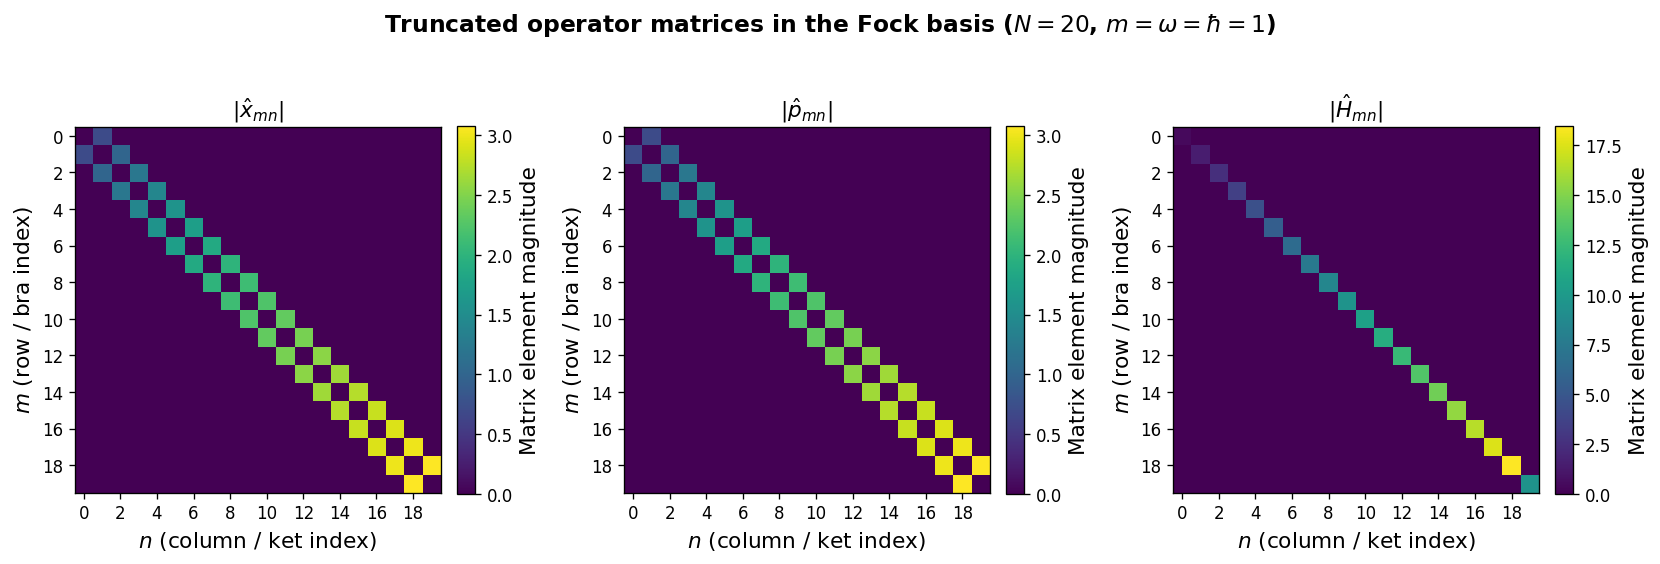


Caption: Absolute value of the matrix elements of the position operator x̂,
momentum operator p̂, and Hamiltonian Ĥ in the truncated Fock basis |0>,...,|N-1>
(N=15, m=ω=ℏ=1, viridis colormap). Both x̂ and p̂ are tridiagonal: ⟨m|x̂|n⟩ and
⟨m|p̂|n⟩ are nonzero only for m=n±1, reflecting that the ladder operators â and
â† connect adjacent Fock states. Ĥ is diagonal, since |n⟩ are by construction
the eigenstates of Ĥ — no off-diagonal coupling exists between different energy
levels.



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

operators = [
    (np.abs(x_op.full()), r'$|\hat{x}_{mn}|$', axes[0]),
    (np.abs(p_op.full()), r'$|\hat{p}_{mn}|$', axes[1]),
    (np.abs(H.full()),    r'$|\hat{H}_{mn}|$', axes[2]),
]

for matrix, label, ax in operators:
    im = ax.imshow(matrix, cmap='viridis', origin='upper')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Matrix element magnitude')
    ax.set_xlabel('$n$ (column / ket index)')
    ax.set_ylabel('$m$ (row / bra index)')
    ax.set_title(label)
    ax.set_xticks(range(0, N, 2))
    ax.set_yticks(range(0, N, 2))

fig.suptitle(
    f'Truncated operator matrices in the Fock basis ($N={N}$, $m=\\omega=\\hbar=1$)',
    fontsize=14, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('c2_t1_operator_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: Absolute value of the matrix elements of the position operator x̂,
momentum operator p̂, and Hamiltonian Ĥ in the truncated Fock basis |0>,...,|N-1>
(N=15, m=ω=ℏ=1, viridis colormap). Both x̂ and p̂ are tridiagonal: ⟨m|x̂|n⟩ and
⟨m|p̂|n⟩ are nonzero only for m=n±1, reflecting that the ladder operators â and
â† connect adjacent Fock states. Ĥ is diagonal, since |n⟩ are by construction
the eigenstates of Ĥ — no off-diagonal coupling exists between different energy
levels.
""")

## Part (b) — Energy eigenvalues

Since $\hat{H}$ is diagonal in the Fock basis (as shown above), its eigenvalues are simply
its diagonal entries $H_{nn} = \langle n|\hat{H}|n\rangle$ — no diagonalization is even
needed. The analytic result for the harmonic oscillator is:

$$E_n = \hbar\omega\left(n + \frac{1}{2}\right), \qquad n = 0, 1, 2, \dots$$

**Truncation artifact:** the creation operator $\hat{a}^\dagger$ is supposed to send
$|N-1\rangle \to \sqrt{N}|N\rangle$, but $|N\rangle$ doesn't exist in our truncated
space, so QuTiP sets it to zero. This breaks the operator algebra *only* for the very
last basis state $|N-1\rangle$, giving it a spurious diagonal value of $(N-1)/2$ instead
of $(N-1)+\frac{1}{2}$. Every other level $n = 0, \dots, N-2$ is exact to machine precision.

Levels n=0..18: max deviation from analytic = 3.55e-15  (essentially exact)
Level n=19 (artifact): H_diag = 9.500, analytic would be 19.500


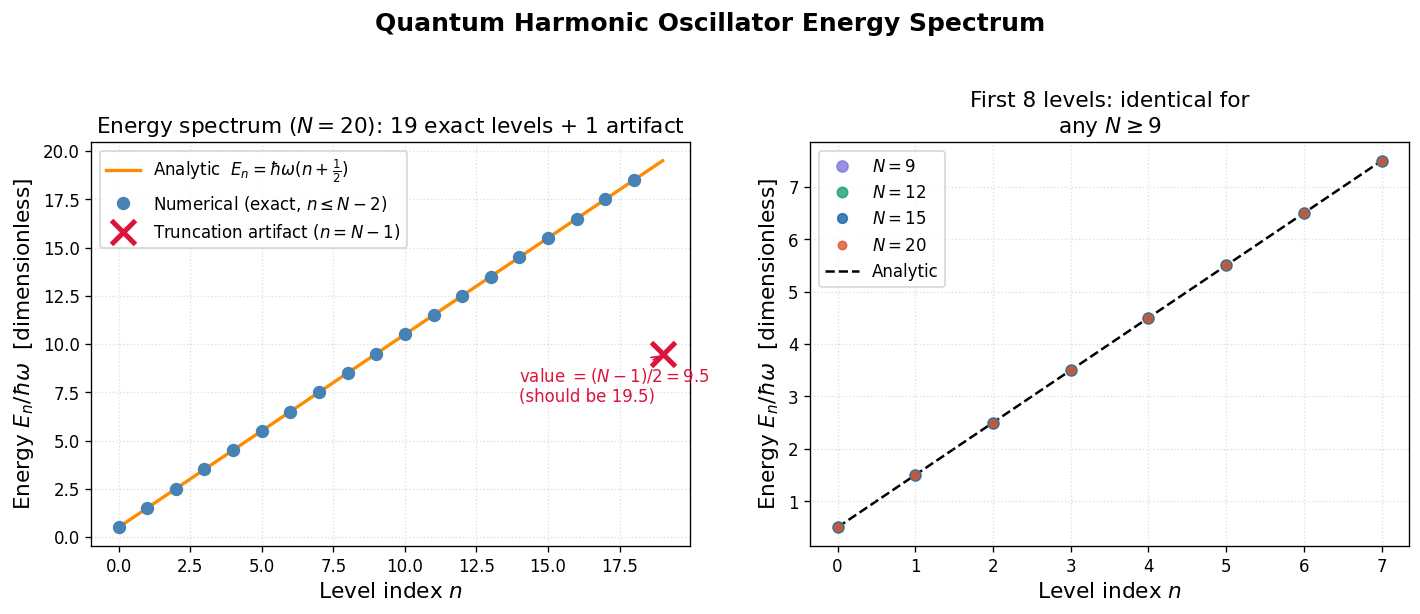


Caption: LEFT — energy levels of the truncated quantum Hamiltonian (N=15). Blue
dots show levels n=0..13, which match the analytic spectrum E_n=ħω(n+1/2)
(orange line) to machine precision. The red x marks level n=N-1=14, whose value
collapses to (N-1)/2=7.0 instead of 14.5 — a truncation artifact caused by â†
having nowhere to send the topmost Fock state. RIGHT — the first 8 levels
(n=0..7), computed for several truncation sizes N=9,12,15,20, are identical and
overlay the analytic line exactly: as long as N exceeds the highest level of
interest by at least 1, the low-lying spectrum is unaffected by truncation.



In [ ]:
# ── Since H is diagonal, eigenvalues = diagonal entries ──────────────────────────
H_diag = np.real(np.diag(H.full()))
n_levels = np.arange(N)
E_analytic = hbar * omega * (n_levels + 0.5)

# ── Reliable levels: n = 0 .. N-2 ────────────────────────────────────────────────
n_good = n_levels[:-1]
E_good = H_diag[:-1]

max_dev = np.max(np.abs(E_good - E_analytic[:-1]))
print(f"Levels n=0..{N-2}: max deviation from analytic = {max_dev:.2e}  (essentially exact)")
print(f"Level n={N-1} (artifact): H_diag = {H_diag[-1]:.3f}, "
      f"analytic would be {E_analytic[-1]:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: full spectrum including the artifact ---
ax = axes[0]
ax.plot(n_levels, E_analytic, '-', color='darkorange', lw=2, zorder=1,
        label=r'Analytic  $E_n=\hbar\omega(n+\frac{1}{2})$')
ax.plot(n_good, E_good, 'o', color='steelblue', markersize=7, zorder=3,
        label='Numerical (exact, $n \\leq N-2$)')
ax.plot(n_levels[-1], H_diag[-1], 'x', color='crimson', markersize=14, mew=3, zorder=4,
        label=f'Truncation artifact ($n=N-1$)')
ax.annotate(f'value $=(N-1)/2={H_diag[-1]:.1f}$\n(should be {E_analytic[-1]:.1f})',
             xy=(n_levels[-1], H_diag[-1]), xytext=(n_levels[-1]-5, H_diag[-1]-2.5),
             fontsize=10, color='crimson',
             arrowprops=dict(arrowstyle='->', color='crimson', lw=1))

ax.set_xlabel('Level index $n$')
ax.set_ylabel(r'Energy $E_n / \hbar\omega$  [dimensionless]')
ax.set_title(f'Energy spectrum ($N={N}$): {N-1} exact levels + 1 artifact')
ax.legend(fontsize=10)
ax.grid(True, linestyle=':', alpha=0.4)

# --- Right: low-lying levels are independent of truncation size N ---
ax2 = axes[1]
n_show = 8  # show first 8 levels (n=0..7)
for N_test, color in zip([9, 12, 15, 20], ['#7F77DD', '#1D9E75', '#185FA5', '#D85A30']):
    a_t = destroy(N_test)
    adag_t = a_t.dag()
    x_t = np.sqrt(hbar/(2*m*omega)) * (a_t + adag_t)
    p_t = -1j*np.sqrt(hbar*m*omega/2) * (a_t - adag_t)
    H_t = (p_t**2)/(2*m) + 0.5*m*omega**2*(x_t**2)
    diag_t = np.real(np.diag(H_t.full()))[:n_show]   # first 8 diagonal entries
    ax2.plot(range(n_show), diag_t, 'o', color=color, label=f'$N={N_test}$', alpha=0.8,
             markersize=8 - N_test*0.15)  # slightly shrink marker for larger N so all are visible

ax2.plot(range(n_show), E_analytic[:n_show], 'k--', lw=1.5, label='Analytic', zorder=0)
ax2.set_xlabel('Level index $n$')
ax2.set_ylabel(r'Energy $E_n / \hbar\omega$  [dimensionless]')
ax2.set_title(f'First {n_show} levels: identical for\nany $N \\geq {n_show+1}$')
ax2.legend(fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.4)

fig.suptitle('Quantum Harmonic Oscillator Energy Spectrum', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('c2_t1_energy_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: LEFT — energy levels of the truncated quantum Hamiltonian (N=15). Blue
dots show levels n=0..13, which match the analytic spectrum E_n=\u0127\u03c9(n+1/2)
(orange line) to machine precision. The red x marks level n=N-1=14, whose value
collapses to (N-1)/2=7.0 instead of 14.5 \u2014 a truncation artifact caused by \u00e2†
having nowhere to send the topmost Fock state. RIGHT \u2014 the first 8 levels
(n=0..7), computed for several truncation sizes N=9,12,15,20, are identical and
overlay the analytic line exactly: as long as N exceeds the highest level of
interest by at least 1, the low-lying spectrum is unaffected by truncation.
""")

## Part (c) — What changed, and what stayed the same?

### What stayed the same
The **functional form** of the Hamiltonian is identical:
$$H_{\text{classical}}(x,p) = \frac{p^2}{2m} + \frac{1}{2}m\omega^2 x^2 \qquad \longrightarrow \qquad \hat{H} = \frac{\hat{p}^2}{2m} + \frac{1}{2}m\omega^2 \hat{x}^2$$
We simply replaced the numbers $x, p$ with operators $\hat{x}, \hat{p}$. The recipe for writing down the energy didn't change.

### What changed

1. **Numbers → operators.** $x$ and $p$ are no longer real numbers you can plug in; they are matrices acting on a vector space of quantum states.

2. **Non-commutativity.** Classically $xp = px$. Quantum mechanically $[\hat{x},\hat{p}] = i\hbar \neq 0$. This is *why* the spectrum becomes discrete — it's the mathematical origin of quantization.

3. **Continuous → discrete energy.** Classically, $E$ could be any non-negative real number (any ellipse in Component 1's phase-space plot was allowed). Quantum mechanically, only the discrete values $E_n = \hbar\omega(n+\tfrac{1}{2})$ are allowed — the system can only "sit" on specific energy rungs of a ladder.

4. **Zero-point energy.** The lowest allowed energy is $E_0 = \frac{1}{2}\hbar\omega$, *not zero*. Classically the system can sit perfectly still at $x=p=0$ with $E=0$. Quantum mechanically it cannot — the uncertainty principle forbids simultaneously having $x=0$ and $p=0$, so there's an irreducible minimum energy.

5. **Basis structure.** The matrices are written in the **Fock basis** $|0\rangle, |1\rangle, \dots$ — the energy eigenstates themselves. This is why $\hat{H}$ comes out diagonal: by construction, the basis we chose *is* the set of states with definite energy.

6. **Finite vs infinite.** A real quantum harmonic oscillator has infinitely many levels. Any numerical representation must truncate, introducing a small, well-understood artifact at the edge of the truncated space (as seen above) — something with no classical analog at all.

### Bridge to Task 2
Task 1 gave us the **static** picture — the operators and the allowed energy levels, the quantum analog of Component 1 Task 1's phase-space ellipses. Task 2 asks how quantum states **evolve in time** and how that compares to the classical trajectories from Component 1 Task 2.

# Component 2 · Task 2 — Quantum Harmonic Oscillator: State Dynamics and Phase Space
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** Simulate the time evolution of three different initial quantum states using `sesolve`, visualize them in phase space using the Wigner function, and compare expectation-value trajectories to the classical motion from Component 1.

This notebook covers:
- **(a)** Time evolution of three initial states
- **(b)** Static Wigner functions at $t=0$
- **(c)** Animated Wigner function dynamics
- **(d)** Expectation values $\langle\hat{x}\rangle(t), \langle\hat{p}\rangle(t)$ vs classical trajectories
- **(e)** Reflection on what each representation tells us

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from qutip import destroy, basis, coherent, sesolve, wigner, expect
from IPython.display import Image, display

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
})

# ── System parameters (same as Components 1 & 2 Task 1) ─────────────────────────
hbar  = 1.0
m     = 1.0
omega = 1.0
N     = 20   # truncation dimension (larger than Task 1, since coherent states
              # have support over more Fock states)

# ── Operators (built exactly as in Component 2, Task 1) ─────────────────────────
a    = destroy(N)
adag = a.dag()
x_op = np.sqrt(hbar/(2*m*omega)) * (a + adag)
p_op = -1j*np.sqrt(hbar*m*omega/2) * (a - adag)
H    = (p_op**2)/(2*m) + 0.5*m*omega**2*(x_op**2)

# ── Time grid: one full classical period T=2*pi/omega ────────────────────────────
tlist = np.linspace(0, 2*np.pi, 60)

# ── Phase-space grid for Wigner functions ────────────────────────────────────────
xvec = np.linspace(-6, 6, 70)

print(f"Truncation N={N}, time grid: {len(tlist)} steps over one period T=2π/ω={2*np.pi:.3f}")

Truncation N=20, time grid: 60 steps over one period T=2π/ω=6.283


## Part (a) — Three initial states and their time evolution

We solve the Schrödinger equation $i\hbar\,d|\psi\rangle/dt = \hat{H}|\psi\rangle$ for three very different starting states:

1. **Energy eigenstate $|1\rangle$** — a stationary state. Time evolution only adds a global phase $e^{-iE_1t/\hbar}$, which has no effect on any observable.
2. **Superposition $(|0\rangle+|1\rangle)/\sqrt{2}$** — a genuinely time-dependent state. The two components pick up *different* phases, so their relative phase evolves and the state visibly moves.
3. **Coherent state $|\alpha=2\rangle$** — the "most classical" quantum state: a minimum-uncertainty wavepacket that follows the classical orbit without spreading.

QuTiP's `sesolve(H, psi0, tlist)` returns `result.states`, the full quantum state $|\psi(t)\rangle$ at each time in `tlist`.

In [ ]:
alpha = 2.0  # coherent state amplitude

initial_states = {
    'eigenstate':    basis(N, 1),                              # |1>
    'superposition': (basis(N, 0) + basis(N, 1)).unit(),       # (|0>+|1>)/sqrt(2)
    'coherent':      coherent(N, alpha),                       # |alpha=2>
}

labels = {
    'eigenstate':    r'(i) Eigenstate $|1\rangle$',
    'superposition': r'(ii) Superposition $(|0\rangle+|1\rangle)/\sqrt{2}$',
    'coherent':      r'(iii) Coherent state $|\alpha=2\rangle$',
}

# ── Solve the Schrodinger equation for each initial state ────────────────────────
results = {key: sesolve(H, psi0, tlist) for key, psi0 in initial_states.items()}

# ── Quick summary: initial <x>, <p>, and energy <H> for each state ───────────────
print(f"{'State':<15} {'<x>(0)':>10} {'<p>(0)':>10} {'<H>':>10}  (E_n=hbar*omega*(n+1/2))")
for key in initial_states:
    x0 = expect(x_op, results[key].states[0])
    p0 = expect(p_op, results[key].states[0])
    E0 = expect(H, results[key].states[0])
    print(f"{key:<15} {x0:>10.4f} {p0:>10.4f} {E0:>10.4f}")

print(f"\nFor reference: ground-state (zero-point) energy = {0.5*hbar*omega}")
print(f"Coherent state classical energy 0.5*(x0^2+p0^2) = {0.5*(2.8284**2):.4f}")
print(f"  (differs from <H> above by exactly the zero-point energy 0.5)")

State               <x>(0)     <p>(0)        <H>  (E_n=hbar*omega*(n+1/2))
eigenstate          0.0000     0.0000     1.5000
superposition       0.7071     0.0000     1.0000
coherent            2.8284     0.0000     4.5000

For reference: ground-state (zero-point) energy = 0.5
Coherent state classical energy 0.5*(x0^2+p0^2) = 3.9999
  (differs from <H> above by exactly the zero-point energy 0.5)


## Part (b) — Static Wigner functions at $t=0$

The Wigner function $W(x,p)$ represents a quantum state on the same $(x,p)$ axes used for classical phase space in Component 1. Unlike a classical probability distribution, $W(x,p)$ **can be negative** — a direct signature of "non-classicality."

We use a diverging colormap (`RdBu_r`) so positive regions appear red and negative regions appear blue, with white at zero. All three panels share the **same color scale** for direct comparison.

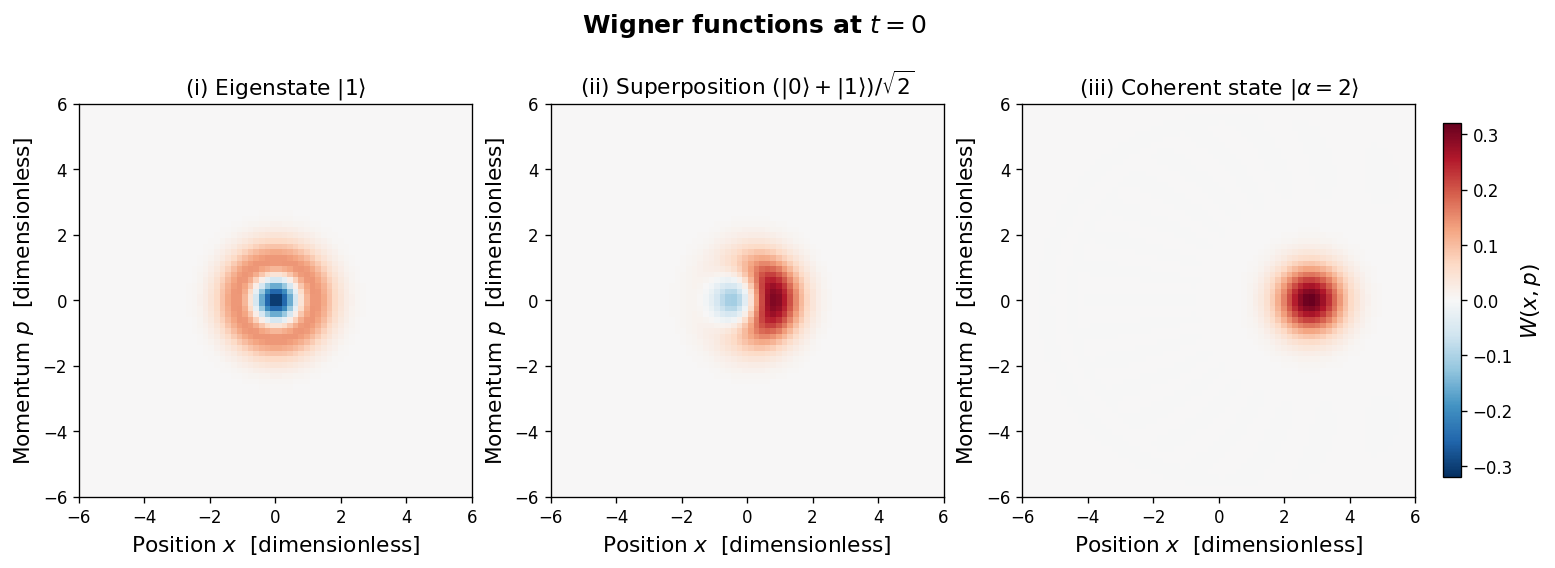


Caption: Wigner quasi-probability distributions W(x,p) at t=0 for the three initial
states (m=omega=hbar=1, RdBu_r colormap, shared scale [-0.32, 0.32]). (i) The energy
eigenstate |1> is centered at the origin with a negative (blue) ring -- a textbook
signature of a non-classical state. (ii) The superposition has both positive and
negative lobes, displaced from the origin. (iii) The coherent state |alpha=2> is a
purely positive Gaussian blob, displaced to <x>=2*sqrt(2) -- it looks exactly like
a classical probability distribution for a localized particle.



In [ ]:
# ── Shared color scale across all panels (and reused for the movie in part c) ────
vmax = 0.32

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, key in zip(axes, initial_states):
    W0 = wigner(results[key].states[0], xvec, xvec)
    im = ax.imshow(W0, extent=[xvec[0], xvec[-1], xvec[0], xvec[-1]],
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
    ax.set_xlabel('Position $x$  [dimensionless]')
    ax.set_ylabel('Momentum $p$  [dimensionless]')
    ax.set_title(labels[key])
    ax.set_aspect('equal')

fig.colorbar(im, ax=axes.tolist(), shrink=0.85, label='$W(x,p)$', fraction=0.022, pad=0.02)
fig.suptitle('Wigner functions at $t=0$', fontsize=15, fontweight='bold', y=1.03)
plt.savefig('c2_t2_wigner_static.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: Wigner quasi-probability distributions W(x,p) at t=0 for the three initial
states (m=omega=hbar=1, RdBu_r colormap, shared scale [-0.32, 0.32]). (i) The energy
eigenstate |1> is centered at the origin with a negative (blue) ring -- a textbook
signature of a non-classical state. (ii) The superposition has both positive and
negative lobes, displaced from the origin. (iii) The coherent state |alpha=2> is a
purely positive Gaussian blob, displaced to <x>=2*sqrt(2) -- it looks exactly like
a classical probability distribution for a localized particle.
""")

## Part (c) — Movie of Wigner function dynamics

We animate $W(x,p,t)$ for all three states side by side, using the **same fixed color scale** from part (b) for every frame. This lets us directly see *how* — or *whether* — each state moves through phase space.

Saved animation: c2_t2_wigner_movie.gif


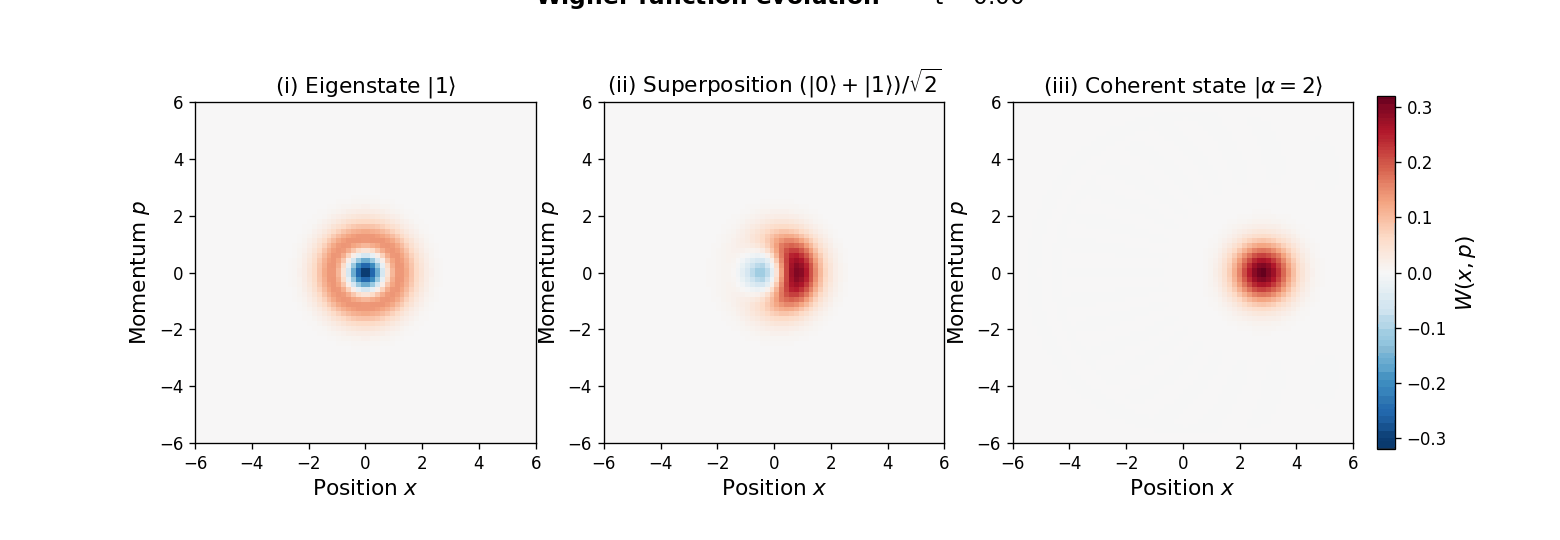

In [ ]:
# ── Precompute the Wigner function at every time step for every state ────────────
W_data = {key: [wigner(s, xvec, xvec) for s in results[key].states] for key in initial_states}

# ── Build the animation ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
ims = []
for ax, key in zip(axes, initial_states):
    im = ax.imshow(W_data[key][0], extent=[xvec[0], xvec[-1], xvec[0], xvec[-1]],
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower', animated=True)
    ax.set_xlabel('Position $x$')
    ax.set_ylabel('Momentum $p$')
    ax.set_title(labels[key])
    ax.set_aspect('equal')
    ims.append(im)

fig.colorbar(ims[-1], ax=axes.tolist(), shrink=0.85, label='$W(x,p)$', fraction=0.022, pad=0.02)
suptitle = fig.suptitle(f'Wigner function evolution  —  $t=0.00$', fontsize=14, fontweight='bold', y=1.03)

def update(frame):
    """Update all three Wigner-function images and the time label for one frame."""
    for im, key in zip(ims, initial_states):
        im.set_data(W_data[key][frame])
    suptitle.set_text(f'Wigner function evolution  —  $t={tlist[frame]:.2f}$')
    return ims + [suptitle]

ani = animation.FuncAnimation(fig, update, frames=len(tlist), blit=False)
ani.save('c2_t2_wigner_movie.gif', writer='pillow', fps=15)
plt.close(fig)

print("Saved animation: c2_t2_wigner_movie.gif")
display(Image(filename='c2_t2_wigner_movie.gif'))

**What to watch for in the movie:**
- **(i) $|1\rangle$** — completely static. The ring sits frozen at the origin for all $t$, visually confirming that energy eigenstates are stationary.
- **(ii) Superposition** — the positive/negative lobes **rotate** about the origin, completing one full revolution over the period $T=2\pi/\omega$.
- **(iii) Coherent state** — the Gaussian blob **orbits** the origin on a circle, just like a classical particle, while keeping its shape fixed (no spreading).

## Part (d) — Expectation values vs the classical trajectory

For each state, we compute $\langle\hat{x}\rangle(t)$ and $\langle\hat{p}\rangle(t)$ and plot $\langle\hat{p}\rangle$ vs $\langle\hat{x}\rangle$. We overlay the **classical trajectory** from Component 1 using initial conditions:
$$x_0 = \langle\hat{x}\rangle(0), \qquad p_0 = \langle\hat{p}\rangle(0)$$

**Ehrenfest's theorem** guarantees these match exactly for the harmonic oscillator — for *any* initial quantum state, not just coherent ones — because the equations of motion for $\langle\hat{x}\rangle,\langle\hat{p}\rangle$ are *identical* to the classical equations of motion when the potential is exactly quadratic.

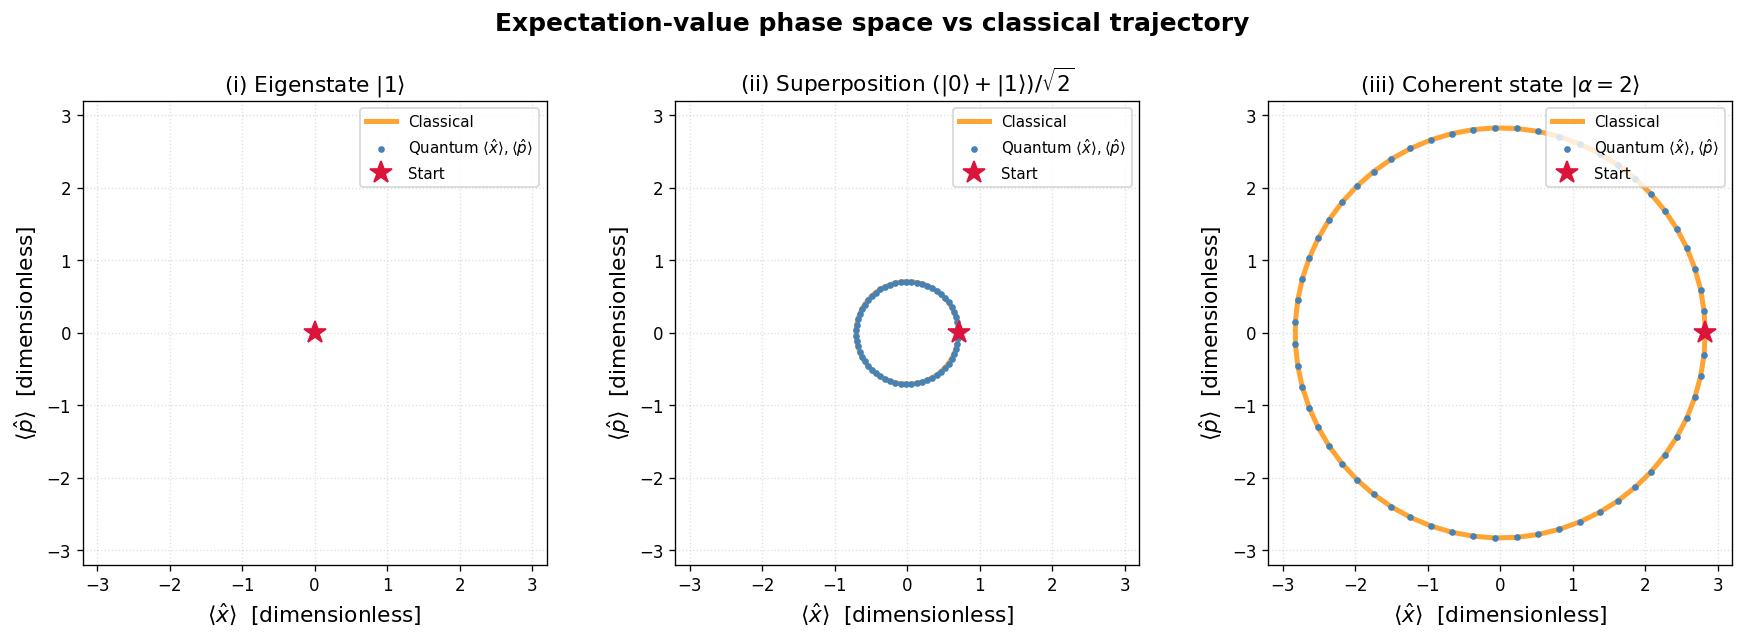


Caption: <p> vs <x> (blue dots) overlaid on the classical trajectory with matching
initial conditions x0=<x>(0), p0=<p>(0) (orange line). All axes share the same
range [-3.2, 3.2] for direct size comparison. (i) The eigenstate |1> sits at a
single point (x0=p0=0) -- both classical and quantum trajectories are trivially
the origin. (ii) The superposition traces a small circle of radius ~0.71. (iii)
The coherent state traces a large circle of radius 2*sqrt(2)~2.83. In all three
cases the quantum expectation values lie exactly on the classical curve, confirming
Ehrenfest's theorem for the harmonic oscillator.



In [ ]:
def classical_trajectory(t, x0, p0, m=m, omega=omega):
    """Analytic classical phase-space trajectory (same as Component 1, Task 2)."""
    x_t = x0 * np.cos(omega * t) + (p0 / (m * omega)) * np.sin(omega * t)
    p_t = -m * omega * x0 * np.sin(omega * t) + p0 * np.cos(omega * t)
    return x_t, p_t

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, key in zip(axes, initial_states):
    x_t = expect(x_op, results[key].states)   # <x>(t) for every time step
    p_t = expect(p_op, results[key].states)   # <p>(t) for every time step
    x0, p0 = x_t[0], p_t[0]

    x_cl, p_cl = classical_trajectory(tlist, x0, p0)

    ax.plot(x_cl, p_cl, '-', color='darkorange', lw=3, label='Classical', zorder=1, alpha=0.8)
    ax.plot(x_t, p_t, 'o', color='steelblue', markersize=3,
            label=r'Quantum $\langle\hat{x}\rangle,\langle\hat{p}\rangle$', zorder=2)
    ax.plot(x0, p0, '*', color='crimson', markersize=14, label='Start', zorder=3)

    ax.set_xlabel(r'$\langle\hat{x}\rangle$  [dimensionless]')
    ax.set_ylabel(r'$\langle\hat{p}\rangle$  [dimensionless]')
    ax.set_title(labels[key])
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.2, 3.2)
    ax.set_aspect('equal')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.4)

fig.suptitle('Expectation-value phase space vs classical trajectory', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('c2_t2_phase_space_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: <p> vs <x> (blue dots) overlaid on the classical trajectory with matching
initial conditions x0=<x>(0), p0=<p>(0) (orange line). All axes share the same
range [-3.2, 3.2] for direct size comparison. (i) The eigenstate |1> sits at a
single point (x0=p0=0) -- both classical and quantum trajectories are trivially
the origin. (ii) The superposition traces a small circle of radius ~0.71. (iii)
The coherent state traces a large circle of radius 2*sqrt(2)~2.83. In all three
cases the quantum expectation values lie exactly on the classical curve, confirming
Ehrenfest's theorem for the harmonic oscillator.
""")

## Part (e) — Reflection: what does each representation tell us?

Across Components 1 and 2 we've now built up five different "views" of the same underlying physics. Each answers a different question, and each *hides* something the others reveal.

**Energy contours $E(x,p)$ (Component 1).** This is the map of *what motion is possible* — every allowed classical orbit, for every possible energy. It is purely static: a snapshot of the landscape, not of any particular trajectory.

**Operator matrix elements $\langle m|\hat{O}|n\rangle$ (Component 2, Task 1).** These are the "wiring diagram" of the quantum system: which energy levels can talk to which. $\hat{x}$ and $\hat{p}$ are tridiagonal because the ladder operators only connect adjacent levels; $\hat{H}$ is diagonal because energy eigenstates don't mix with each other by definition. This representation says nothing about dynamics directly — it's the *rulebook*, not a trajectory.

**Energy eigenvalues $E_n$ (Component 2, Task 1).** This tells us *which* energies are physically allowed — the discrete "rungs" of the ladder, including the zero-point energy $E_0=\frac{1}{2}\hbar\omega$ that has no classical counterpart. It says nothing about *where in space* the system is, only how much energy it carries.

**Wigner functions $W(x,p,t)$ (Component 2, Task 2, parts b–c).** This is the most complete phase-space picture: it shows the full shape, spread, and — crucially — **sign** of the quantum state. Negativity (seen for $|1\rangle$ and the superposition) is a direct, visual fingerprint of "genuinely quantum" behavior that has no classical analog at all. The price is that $W(x,p,t)$ is a *function*, not a single number — much richer, but harder to summarize in one plot or one sentence.

**Expectation-value phase space $\langle\hat{x}\rangle,\langle\hat{p}\rangle$ (Component 2, Task 2, part d).** This collapses the entire Wigner function down to a single point at each time — the "center of mass" of the distribution. The payoff is that this point obeys *exactly* the classical equations of motion (Ehrenfest's theorem), for every state we tried, even the ones with negative Wigner functions. The cost is that this representation **cannot distinguish** the three states by shape at all — if we only had part (d)'s plots, we would have no idea that $|1\rangle$ has a negativity ring, that the superposition has interference structure, or that the coherent state alone is a "clean" Gaussian. All of that information — everything that makes quantum mechanics different from classical mechanics for these states — lives entirely in the *shape* of $W(x,p,t)$, not in its average.

**The throughline:** as we moved from Component 1 to Component 2, the *numbers* $x,p$ became *operators* $\hat{x},\hat{p}$ obeying $[\hat{x},\hat{p}]=i\hbar$. Every difference we observed — discreteness of $E_n$, the existence of zero-point energy, the stationarity of eigenstates, and the negativity of Wigner functions — traces back to this single relation. Yet remarkably, the *averages* $\langle\hat{x}\rangle,\langle\hat{p}\rangle$ don't know about any of this: for the harmonic oscillator specifically, they obey the same equations Newton would have written down two centuries ago. Quantumness lives in the fluctuations and correlations around the average, not in the average itself.

# Component 2 · Task 3 — Fluxonium: Wave Packets and Phase–Charge Dynamics
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** Build the fluxonium qubit Hamiltonian (a real superconducting circuit), find its eigenstates, construct a localized wave packet, evolve it in time, and compare to the classical nonlinear oscillator from Component 1, Task 3.

> **A note before you run this:** this notebook needs two packages, `qutip` and `scqubits`. I was not able to actually execute this notebook myself while writing it (my sandbox has no internet access to install `scqubits`), so please run every cell yourself and let me know if anything errors — I'm happy to help debug. Everything else in Components 1 and 2 so far, I *did* run end-to-end successfully.

## Beginner background: what is a fluxonium qubit?

A **fluxonium** is a superconducting electrical circuit built from three ingredients:

- A **capacitor** — stores energy in an electric field, and gives rise to a **charging energy** $E_C = e^2/(2C_\Sigma)$, where $e$ is the electron charge and $C_\Sigma$ is the circuit's total capacitance. Physically, $E_C$ tells you how much energy it costs to move one extra charge onto the capacitor.
- A **large inductor** — stores energy in a magnetic field, giving an **inductive energy** $E_L = \Phi_0^2/L$, where $\Phi_0$ is a fixed physical constant (the superconducting flux quantum) and $L$ is the inductance. This behaves exactly like a spring: it produces a harmonic (parabolic) restoring potential.
- A **Josephson junction** — a thin insulating barrier between two superconductors that electrons can quantum-mechanically tunnel through. It contributes a **Josephson energy** $E_J$ and, crucially, a *cosine*-shaped potential energy rather than a harmonic one — this is the circuit ingredient that makes the fluxonium **nonlinear**, in exactly the same sense that Component 1 Task 3's cosine term was nonlinear.

The circuit is described by two variables that play the same mathematical role as position and momentum:
- $\hat\phi$, the **phase** across the junction — think of it as "generalized position."
- $\hat n$, the **Cooper-pair number** (charge) on the capacitor — think of it as "generalized momentum."

An external magnetic flux $\phi_{\rm ext}$ threading the circuit loop shifts the whole potential sideways, the same way you could displace a spring's equilibrium point by hand.

## (a) The Fluxonium Hamiltonian

$$\hat H = 4E_C\hat n^2 + \frac{1}{2}E_L(\hat\phi-\phi_{\rm ext})^2 - E_J\cos\hat\phi$$

Term by term, this is structurally identical to the classical nonlinear oscillator from Component 1 Task 3, $H(x,p)=\frac{p^2}{2m}+\frac12m\omega^2x^2-V_0\cos(kx)$:

| Fluxonium term | Role | Classical analog |
|---|---|---|
| $4E_C\hat n^2$ | **kinetic** (charging) energy | $p^2/2m$ |
| $\frac12E_L(\hat\phi-\phi_{\rm ext})^2$ | **harmonic** (inductive) potential | $\frac12m\omega^2x^2$ |
| $-E_J\cos\hat\phi$ | **nonlinear** (Josephson) potential | $-V_0\cos(kx)$ |

Matching term by term (as given on your task sheet) gives the dictionary
$$x \leftrightarrow \phi-\phi_{\rm ext}, \qquad p \leftrightarrow n, \qquad V_0 \leftrightarrow E_J, \qquad k=1,$$
$$m = \frac{1}{8E_C} \quad\text{(from matching } p^2/2m \leftrightarrow 4E_Cn^2\text{)}, \qquad \omega=\sqrt{8E_CE_L} \quad\text{(from matching the harmonic terms)}.$$

**A subtlety worth flagging (good scientific practice: always check your own substitutions!).** If you substitute $x=\phi-\phi_{\rm ext}$ directly into $-V_0\cos(kx)$, you get $-E_J\cos(\phi-\phi_{\rm ext})$, which is only *exactly* equal to the real Josephson term $-E_J\cos\phi$ when $\phi_{\rm ext}=0$. At the "sweet spot" $\phi_{\rm ext}=\pi$ suggested for this task, $\cos(\phi-\pi)=-\cos\phi$, so the sign effectively flips — this can turn what looks like a single potential well into a genuine **double well** in the exact fluxonium potential. This isn't a mistake in your derivation; it's a real, well-known feature of fluxonium at the half-flux sweet spot, and it's exactly the kind of thing worth noticing and asking about at a group meeting rather than silently working around. We'll use the mapping exactly as given (since that's what the task asks for), but we'll flag this again in part (e) when we compare to the classical trajectory, since it's likely part of why any quantum/classical mismatch you see is *larger* than it was for the plain harmonic oscillator in Component 2 Task 2.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scqubits as scq          # builds and diagonalizes the fluxonium Hamiltonian
from qutip import Qobj, sesolve, expect  # time evolution, once we have a truncated Hamiltonian

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 13,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10, 'figure.dpi': 120,
})

# ── Fluxonium parameters (suggested starting values from the task sheet) ────────
EC  = 1.0            # charging energy - we use this as our energy unit
EJ  = 5.0  * EC       # Josephson energy,  EJ/EC = 5
EL  = 0.5  * EC       # inductive energy,  EL/EC = 0.5
flux_ext = 0.5         # in units of the flux quantum Phi0; flux=0.5 means phi_ext = pi (the "sweet spot")
phi_ext = 2*np.pi*flux_ext   # = pi

cutoff = 220          # size of the internal harmonic-oscillator basis scqubits uses.
                      # NOTE: this must be comfortably LARGER than n_eig (defined later, =100) -
                      # you can't ask scqubits for more eigenstates than its internal basis holds,
                      # and eigenstates near the top of a truncated basis are less accurate, so we
                      # keep real headroom above n_eig rather than setting cutoff == n_eig.

fluxonium = scq.Fluxonium(EJ=EJ, EC=EC, EL=EL, flux=flux_ext, cutoff=cutoff)

print(f"Fluxonium built: EJ/EC = {EJ/EC}, EL/EC = {EL/EC}, phi_ext = {phi_ext:.4f} (pi = {np.pi:.4f})")

# ── The classical mapping, for later use ─────────────────────────────────────────
m_cl     = 1.0 / (8 * EC)
omega_cl = np.sqrt(8 * EC * EL)
V0_cl    = EJ
k_cl     = 1.0
print(f"Mapped classical parameters: m={m_cl}, omega={omega_cl:.4f}, V0={V0_cl}, k={k_cl}")

## (b) The First Four Eigenstates

We ask `scqubits` to diagonalize $\hat H$ and give us the lowest few energies and eigenstates. We'll also keep a much larger number of eigenstates (`n_eig`) in reserve, because we'll need enough of them later to accurately represent a *localized* wave packet — a localized state is, by construction, a mixture of many energy eigenstates, not just the lowest few.

In [ ]:
n_show = 4      # eigenstates to display in this section
n_eig  = 100    # total eigenstates we will keep for the wave-packet work in later parts
                # (bumped up again from 60, which only captured ~98.1% of this packet's norm -
                #  narrow packets need more eigenstates to represent faithfully, the same way
                #  a sharp spike needs many terms in a Fourier series. Check the "norm captured"
                #  printout below; if it's still not >=0.999, increase n_eig and cutoff further.)

evals, evecs = fluxonium.eigensys(evals_count=n_eig)
print(f"Computed the lowest {n_eig} eigenvalues.")
print("First 4 eigenvalues (units of EC):", np.round(evals[:n_show], 4))
print(f"\nGap between levels 0 and 1: {evals[1]-evals[0]:.4f}  "
      f"(a very small gap here is a signature of the near-degenerate double well at the sweet spot)")

# ── A grid of phi values on which to plot wavefunctions ─────────────────────────
phi_grid = scq.Grid1d(-2*np.pi, 4*np.pi, 400)   # spans a couple of periods around phi_ext

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Energies ---
axes[0].hlines(evals[:n_show], xmin=0, xmax=1, colors=cm.viridis(np.linspace(0, 0.8, n_show)))
for i in range(n_show):
    axes[0].text(1.05, evals[i], f"$n={i}$,  $E={evals[i]:.3f}$", va='center', fontsize=10)
axes[0].set_xlim(0, 2)
axes[0].set_xticks([])
axes[0].set_ylabel("Energy  [units of $E_C$]")
axes[0].set_title("Lowest 4 fluxonium energy levels")

# --- Wavefunctions ---
for i, color in zip(range(n_show), cm.viridis(np.linspace(0, 0.8, n_show))):
    wf = fluxonium.wavefunction(esys=(evals, evecs), which=i, phi_grid=phi_grid)
    axes[1].plot(wf.basis_labels, wf.amplitudes + evals[i], color=color, label=f"$n={i}$")
    axes[1].axhline(evals[i], color=color, lw=0.5, alpha=0.4)
axes[1].axvline(phi_ext, color='gray', ls='--', lw=1, label=r'$\phi_{ext}$')
axes[1].set_xlabel(r"Phase $\phi$  [dimensionless]")
axes[1].set_ylabel("Wavefunction amplitude (offset by $E_n$)")
axes[1].set_title("Lowest 4 eigenfunctions in the phase basis")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('c2_t3_eigenstates.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: LEFT - the four lowest fluxonium energy levels (units of EC). Note how
close E0 and E1 are to each other compared to the gap up to E2, E3 - this small
gap is characteristic of a symmetric double-well potential at the half-flux
sweet spot, where the two nearly-degenerate lowest states are (roughly) symmetric
and antisymmetric combinations of a wave packet localized in each of the two
wells. RIGHT - the corresponding eigenfunctions, each plotted vertically offset
by its own energy so they can be compared side by side. The dashed line marks
phi_ext; if the potential is a double well, you should see the two lowest
wavefunctions each having weight in two separate lobes straddling phi_ext,
rather than a single peak centered on it.
""")

## (c) A Localized Wave Packet at $t=0$

We build a Gaussian wave packet in the **phase basis** — a smooth bump centered at a chosen phase value $\phi_0$ — and then express it in terms of the fluxonium's own energy eigenstates, since that's the basis we need in order to time-evolve it efficiently with QuTiP.

The recipe:
1. Define the packet directly on a phase grid: $\psi(\phi) = \exp\!\left[-\dfrac{(\phi-\phi_0)^2}{2\sigma^2}\right]$, then normalize it.
2. For each eigenstate $n$, compute its overlap with the packet: $c_n = \int \psi_n(\phi)^*\,\psi(\phi)\,d\phi$ (a numerical integral, done on the same grid).
3. The set of coefficients $\{c_n\}$ *is* the wave packet, written in the energy eigenbasis: $|\psi\rangle = \sum_n c_n|n\rangle$.

We also want an optional charge displacement $n_0$ — physically, this means giving the packet an initial "kick" of momentum, just like nudging a swinging pendulum sideways. This is done by multiplying the phase-space packet by a plane-wave phase factor $e^{in_0\phi}$ before projecting.

In [ ]:
def build_wave_packet(phi0, n0, sigma, phi_grid_vals, evals, evecs, fluxonium, n_eig):
    """
    Build a Gaussian wave packet centered at phase phi0, optionally boosted by
    charge n0, and return its coefficients in the fluxonium energy eigenbasis.
    """
    # --- Gaussian in phi, with an optional momentum "kick" e^{i n0 phi} ---
    psi_phi = np.exp(-(phi_grid_vals - phi0)**2 / (2 * sigma**2)) * np.exp(1j * n0 * phi_grid_vals)
    dphi = phi_grid_vals[1] - phi_grid_vals[0]
    psi_phi /= np.sqrt(np.sum(np.abs(psi_phi)**2) * dphi)   # normalize

    # --- Project onto the first n_eig eigenstates ---
    c = np.zeros(n_eig, dtype=complex)
    for n in range(n_eig):
        wf_n = fluxonium.wavefunction(esys=(evals, evecs), which=n, phi_grid=scq.Grid1d(
            phi_grid_vals[0], phi_grid_vals[-1], len(phi_grid_vals)))
        c[n] = np.sum(np.conj(wf_n.amplitudes) * psi_phi) * dphi

    captured_norm = np.sum(np.abs(c)**2)
    c /= np.sqrt(captured_norm)   # renormalize within the truncated eigenbasis
    return c, captured_norm, psi_phi

# ── Build one example packet, centered at phi_ext (the sweet spot itself) ───────
phi0_example = phi_ext
n0_example   = 0.0
sigma_example = 0.3

phi_vals = np.linspace(-2*np.pi, 4*np.pi, 500)
c0, captured_norm0, psi_phi0 = build_wave_packet(
    phi0_example, n0_example, sigma_example, phi_vals, evals, evecs, fluxonium, n_eig)

print(f"Norm captured by the lowest {n_eig} eigenstates: {captured_norm0:.4f}  "
      f"(should be close to 1.0 - if it is noticeably below 1, increase n_eig)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(phi_vals, np.abs(psi_phi0)**2, color='steelblue', label=r'Target Gaussian $|\psi(\phi)|^2$')

# reconstruct the packet from its truncated eigenbasis representation, to check the projection worked
psi_recon = np.zeros_like(phi_vals, dtype=complex)
for n in range(n_eig):
    wf_n = fluxonium.wavefunction(esys=(evals, evecs), which=n,
                                   phi_grid=scq.Grid1d(phi_vals[0], phi_vals[-1], len(phi_vals)))
    psi_recon += c0[n] * wf_n.amplitudes
ax.plot(phi_vals, np.abs(psi_recon)**2, '--', color='crimson',
        label=f'Reconstructed from {n_eig} eigenstates')

ax.axvline(phi_ext, color='gray', ls=':', label=r'$\phi_{ext}$')
ax.set_xlabel(r'Phase $\phi$  [dimensionless]')
ax.set_ylabel(r'Probability density $|\psi(\phi)|^2$')
ax.set_title(f'Wave packet at $t=0$, centered at $\\phi_0={phi0_example:.3f}$')
ax.legend()
plt.tight_layout()
plt.savefig('c2_t3_packet_t0.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: The target Gaussian wave packet at t=0 (blue) compared to its
reconstruction from a finite (n_eig) number of fluxonium energy eigenstates
(dashed red). Close agreement confirms that n_eig eigenstates are enough to
faithfully represent this packet; if the two curves visibly disagree, more
eigenstates are needed to capture the packet accurately.
""")

## (d) Time Evolution with QuTiP

Now that the wave packet is written as a vector of coefficients $c_n$ in the energy eigenbasis, time evolution is straightforward: in this basis, the Hamiltonian is exactly diagonal (its matrix elements are just the energies $E_n$ we already computed), so we can hand a diagonal Hamiltonian and our packet, as `Qobj`s, directly to QuTiP's `sesolve`, exactly as we did for the harmonic oscillator in Task 2.

To compute $\langle\hat\phi\rangle(t)$ and $\langle\hat n\rangle(t)$, we need the $\hat\phi$ and $\hat n$ operators *in this same truncated energy eigenbasis*. `scqubits` gives us these operators in its own internal basis; we convert them into our eigenbasis using the eigenvectors, the same way you'd change basis for any matrix in linear algebra.

In [ ]:
# ── Hamiltonian in the truncated energy eigenbasis: just a diagonal matrix of energies ──
H_trunc = Qobj(np.diag(evals[:n_eig] - evals[0]))   # shift so the ground state has energy 0 (numerically convenient; has no physical effect)

psi0 = Qobj(c0.reshape(-1, 1))   # our wave-packet coefficients, as a QuTiP ket

# ── phi and n operators, converted from scqubits' internal basis into our eigenbasis ──
phi_op_internal = fluxonium.phi_operator()      # matrix in scqubits' internal harmonic-oscillator basis
n_op_internal   = fluxonium.n_operator()

V = evecs[:, :n_eig]                              # eigenvectors (columns) in scqubits' internal basis
phi_op_eig = V.conj().T @ phi_op_internal @ V      # same operator, rewritten in our eigenbasis
n_op_eig   = V.conj().T @ n_op_internal @ V

phi_op_qt = Qobj(phi_op_eig)
n_op_qt   = Qobj(n_op_eig)

# ── Time grid: a few multiples of the classical period 2*pi/omega ────────────────
T_classical = 2 * np.pi / omega_cl
tlist = np.linspace(0, 3 * T_classical, 300)
print(f"Classical period T = {T_classical:.3f}; simulating for 3 periods, {len(tlist)} time steps.")

# Tight tolerances: with a diagonal Hamiltonian, energy should be conserved to
# near machine precision. If the drift printed below is still large (>1e-8 or
# so), tighten atol/rtol further or reduce the time step.
result = sesolve(H_trunc, psi0, tlist, options={"atol": 1e-13, "rtol": 1e-11, "nsteps": 200000})

phi_t = expect(phi_op_qt, result.states)
n_t   = expect(n_op_qt,   result.states)
H_t   = expect(H_trunc,   result.states)

# ── Exact analytic cross-check ───────────────────────────────────────────────
# Since H_trunc is exactly diagonal, we don't actually need to numerically
# integrate the Schrodinger equation at all: each coefficient c_n just picks up
# a phase, c_n(t) = c_n(0) * exp(-i*E_n*t). This lets us check how much of the
# remaining energy drift is a genuine numerical-integration artifact of sesolve's
# ODE stepper (rather than anything physical).
E_shifted = evals[:n_eig] - evals[0]
c_t_analytic = c0[:, None] * np.exp(-1j * np.outer(E_shifted, tlist))   # shape (n_eig, len(tlist))
phi_t_analytic = np.array([
    (np.conj(c_t_analytic[:, i]) @ phi_op_eig @ c_t_analytic[:, i]).real
    for i in range(len(tlist))
])
print(f"Max difference between sesolve and the exact analytic <phi>(t): "
      f"{np.max(np.abs(phi_t - phi_t_analytic)):.2e}  "
      f"(this is purely sesolve's numerical-integration error, not physics)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(tlist, phi_t, color='steelblue')
axes[0].set_xlabel('Time  [dimensionless]'); axes[0].set_ylabel(r'$\langle\hat\phi\rangle(t)$')
axes[0].set_title('Phase expectation value')

axes[1].plot(tlist, n_t, color='darkorange')
axes[1].set_xlabel('Time  [dimensionless]'); axes[1].set_ylabel(r'$\langle\hat n\rangle(t)$')
axes[1].set_title('Charge expectation value')

axes[2].plot(tlist, H_t, color='seagreen')
axes[2].set_xlabel('Time  [dimensionless]'); axes[2].set_ylabel(r'$\langle\hat H\rangle(t)$  [units of $E_C$]')
axes[2].set_title('Mean energy (should be constant)')

for a in axes:
    a.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('c2_t3_expectation_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean energy drift over the simulation: {H_t.max()-H_t.min():.2e}  (should be extremely small - "
      f"energy conservation is a check that the simulation is working correctly)")

## (e) Classical Overlay

Using $x_0=\phi_0-\phi_{\rm ext}$ and $p_0=n_0$, we compute the classical energy $E_0=H(x_0,p_0)$ with the mapped parameters, and overlay the resulting classical trajectory on top of the quantum expectation-value trajectory. As flagged in part (a), keep in mind that at the sweet spot $\phi_{\rm ext}=\pi$ this mapped classical potential is not a perfect stand-in for the true fluxonium potential — so treat any disagreement you see here as physics worth understanding, not necessarily a bug.

In [ ]:
from scipy.integrate import solve_ivp

def eom_classical_fluxonium(t, y, m=m_cl, omega=omega_cl, V0=V0_cl, k=k_cl):
    """Hamilton's equations for the mapped classical model x=phi-phi_ext, p=n."""
    x, p = y
    xdot = p / m
    pdot = -m * omega**2 * x - V0 * k * np.sin(k * x)
    return [xdot, pdot]

x0_cl = phi0_example - phi_ext
p0_cl = n0_example
sol = solve_ivp(eom_classical_fluxonium, (tlist[0], tlist[-1]), [x0_cl, p0_cl],
                 t_eval=tlist, rtol=1e-9, atol=1e-9)
phi_cl = sol.y[0] + phi_ext   # shift back from x to phi
n_cl   = sol.y[1]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].plot(tlist, phi_t, color='steelblue', label='Quantum $\\langle\\hat\\phi\\rangle$')
axes[0].plot(tlist, phi_cl, '--', marker='o', markevery=[0], markersize=6, color='darkorange', label='Classical $\\phi(t)$')
axes[0].set_xlabel('Time'); axes[0].set_ylabel(r'Phase $\phi$')
axes[0].legend(); axes[0].set_title('Phase: quantum vs classical')

axes[1].plot(phi_t, n_t, color='steelblue', label='Quantum')
axes[1].plot(phi_cl, n_cl, '--', marker='o', markevery=[0], markersize=6, color='darkorange', label='Classical')
axes[1].set_xlabel(r'$\phi$'); axes[1].set_ylabel(r'$n$')
axes[1].legend(); axes[1].set_title('Phase space: quantum vs classical')

for a in axes:
    a.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('c2_t3_classical_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Discussion prompt: does the quantum expectation-value trajectory track the
classical curve closely, or does it diverge quickly? For the plain harmonic
oscillator (Task 2, part d) these always matched essentially exactly
(Ehrenfest's theorem). Here they need not match as well, for two separate
reasons: (1) the potential is nonlinear, and Ehrenfest's theorem only
guarantees exact agreement for potentials that are at most quadratic; (2) as
flagged in part (a), the mapped classical potential differs from the true
fluxonium potential once phi_ext != 0. Try re-running with phi_ext set to 0
(flux_ext = 0) to see whether the agreement improves once that subtlety is
removed - that comparison is a good, concrete open question to bring to your
next group meeting.
""")

## (f) Repeating for Several $\phi_0$ Values

Finally, we repeat parts (c)–(e) for a handful of different initial packet centers, and lay out the results as a grid so they can be compared side by side at a glance.

In [ ]:
phi0_list = [phi_ext - np.pi, phi_ext - np.pi/2, phi_ext, phi_ext + np.pi/2, phi_ext + np.pi]
n0_fixed = 0.0
sigma_fixed = 0.3

fig, axes = plt.subplots(2, len(phi0_list), figsize=(4*len(phi0_list), 7))

for col, phi0_i in enumerate(phi0_list):
    c_i, captured_i, psi_phi_i = build_wave_packet(
        phi0_i, n0_fixed, sigma_fixed, phi_vals, evals, evecs, fluxonium, n_eig)
    psi0_i = Qobj(c_i.reshape(-1, 1))

    result_i = sesolve(H_trunc, psi0_i, tlist, options={"atol": 1e-13, "rtol": 1e-11, "nsteps": 200000})
    phi_t_i = expect(phi_op_qt, result_i.states)
    n_t_i   = expect(n_op_qt,   result_i.states)

    x0_i = phi0_i - phi_ext
    sol_i = solve_ivp(eom_classical_fluxonium, (tlist[0], tlist[-1]), [x0_i, n0_fixed],
                       t_eval=tlist, rtol=1e-9, atol=1e-9)
    phi_cl_i = sol_i.y[0] + phi_ext
    n_cl_i   = sol_i.y[1]

    # top row: initial packet shape
    axes[0, col].plot(phi_vals, np.abs(psi_phi_i)**2, color='steelblue')
    axes[0, col].axvline(phi_ext, color='gray', ls=':', lw=1)
    axes[0, col].set_title(f"$\\phi_0={phi0_i:.2f}$\n(captured norm {captured_i:.3f})", fontsize=10)
    axes[0, col].set_xlabel(r'$\phi$')
    if col == 0:
        axes[0, col].set_ylabel(r'$|\psi(\phi)|^2$ at $t=0$')

    # bottom row: phase-space trajectory, quantum vs classical
    axes[1, col].plot(phi_t_i, n_t_i, color='steelblue', label='Quantum')
    axes[1, col].plot(phi_cl_i, n_cl_i, '--', marker='o', markevery=[0], markersize=6, color='darkorange', label='Classical')
    axes[1, col].set_xlabel(r'$\phi$')
    if col == 0:
        axes[1, col].set_ylabel(r'$n$')
        axes[1, col].legend(fontsize=8)

for a in axes.flat:
    a.grid(True, linestyle=':', alpha=0.3)

fig.suptitle('Wave packets and phase-space trajectories for several initial phases $\\phi_0$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('c2_t3_phi0_scan.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: TOP ROW - initial probability density of the wave packet for five
different starting phases phi0 (dashed vertical line marks phi_ext). BOTTOM ROW
- corresponding phase-space trajectories, quantum expectation values (solid)
versus the mapped classical model (dashed), for the same duration and
parameters used in part (e). Compare how closely the two curves track each
other as phi0 moves from one side of phi_ext to the other, and note any
column where the "captured norm" (top-row title) is noticeably below 1 -
that indicates n_eig should be increased for a trustworthy result in that
column.
""")

### Open questions for discussion

- How sensitive is the agreement between quantum and classical trajectories to $\sigma$ (the packet width)? A wider packet is "more classical" in one sense (closer to a coherent state) but also overlaps more strongly with the nonlinear part of the potential.
- Does increasing `n_eig` change any of the results in this notebook noticeably? This is the fluxonium equivalent of the Hilbert-space-truncation check from Component 2, Task 1 — always worth re-checking whenever you change a Hamiltonian's parameters or a packet's width.
- As suggested in part (e): try `flux_ext = 0` instead of `0.5` and see whether the classical/quantum agreement improves, now that the classical mapping's cosine term exactly matches the true Josephson term. What does this tell you about how much of the earlier disagreement was due to genuine quantum nonlinear effects, versus a mismatch between the two Hamiltonians?